Our First ML Sprint

We'll spend the next sessions on:

Session 1
* Understand the ML problem
* Define the target
* Identify features
* Detect data leakage
* Build the first baseline model

Session 2
* Evaluate performance
* Improve the model
* Interpret predictions

Session 3
* Save the trained model
* Build a prediction pipeline

Only after we have a reliable model will we move on to APIs, Docker, and AI features.

When should a prediction be made?

There are several possibilities:

Option A — At Order Placement 

Information available:

* Customer location
* Seller location
* Product details
* Freight cost
* Shipping limit
* Payment information

Business benefit:

* Warn the customer immediately.
* Adjust estimated delivery dates.
* Prioritize risky orders before processing.

Option B — After Seller Ships the Order

Now we also know:

* Carrier assigned
* Shipping timestamp

Prediction becomes easier.

Option C — Halfway Through Delivery

* By then, the shipment is already in transit.

* Prediction is more accurate but less useful because there is little time to intervene.

#### There we stick with option A which help business to arrange/priortize Orders to deliver priorly instead of delaying

* Safe Features (Available at Order Placement)

* Examples:

* Product category
* Product weight
* Product dimensions
* Seller state
* Seller city
* Customer state
* Customer city
* Freight value
* Price
* Shipping limit date
* Purchase month
* Purchase weekday
* Purchase hour
* High freight flag
* Heavy product flag
* Large product flag

These are all known before the order is shipped.

Unsafe Features (Future Information)

Examples:

* order_approved_at
* order_delivered_carrier_date
* order_delivered_customer_date
* delivery_time_days
* shipping_time_days
* approval_time_hours
* delivery_delay_days
* review_score

### Pipeline for this Late Delivery Prediction
Business Problem

↓

Understand Data

↓

Prevent Leakage

↓

Feature Selection

↓

Preprocessing

↓

Split Data

↓

Benchmark Models

↓

Cross Validation

↓

Hyperparameter Tuning

↓

Evaluation

↓

Explainability

↓

Deployment

↓

Monitoring 

# Late Delivery Prediction

## Business Problem

Can we predict whether an order will be delivered late before it is shipped?

Business Value

- Improve customer satisfaction
- Reduce logistics delays
- Prioritize risky orders
- Improve delivery estimates

Target

late_delivery_flag

Problem Type

Binary Classification

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

Section 3 — Initial Inspection of Dataset and loaded

In [2]:
DATA_PATH = Path("../data/processed/final_processed_datasets")

fact_orders = pd.read_csv(
    DATA_PATH / "fact_orders_fe.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ]
)

sales_fact = pd.read_csv(
    DATA_PATH / "sales_fact_fe.csv",
    parse_dates=[
        "shipping_limit_date",
        "order_purchase_timestamp",
    ]
)

Section 4 — Initial Inspection

In [3]:
print("="*50)
print("FACT ORDERS")
print("="*50)

print(fact_orders.shape)

fact_orders.head()

FACT ORDERS
(99441, 42)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_after_carrier_flag,late_delivery_flag,delivery_before_carrier_flag,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment,payment_count,payment_type,max_installments,review_score,review_comment_title,review_comment_message,purchase_year,purchase_month,purchase_month_name,purchase_quarter,purchase_day,purchase_weekday,purchase_hour,approval_time_hours,shipping_time_days,delivery_time_days,total_order_cycle_days,estimated_delivery_days,delivery_delay_days,avg_payment_per_installment,multiple_payment_methods,high_rating,low_rating,is_delivered,is_cancelled,is_in_progress
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,False,False,False,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,3.00,"credit_card, voucher",1.00,4.00,NaN,"Não testei o produto ainda, mas ele veio corre...",2017,10,October,4,2,Monday,10,0.18,2.00,6.00,8.00,15,-8.00,38.71,True,True,False,True,False,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,False,False,False,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.00,boleto,1.00,4.00,Muito boa a loja,Muito bom o produto.,2018,7,July,3,24,Tuesday,20,30.71,0.00,12.00,13.00,19,-6.00,141.46,False,True,False,True,False,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,False,False,False,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,1.00,credit_card,3.00,5.00,NaN,NaN,2018,8,August,3,8,Wednesday,8,0.28,0.00,9.00,9.00,26,-18.00,59.71,False,True,False,True,False,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,False,False,False,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,1.00,credit_card,1.00,5.00,NaN,O produto foi exatamente o que eu esperava e e...,2017,11,November,4,18,Saturday,19,0.30,3.00,9.00,13.00,26,-13.00,72.20,False,True,False,True,False,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,False,False,False,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,1.00,credit_card,1.00,5.00,NaN,NaN,2018,2,February,1,13,Tuesday,21,1.03,0.00,1.00,2.00,12,-10.00,28.62,False,True,False,True,False,False


In [4]:
fact_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 42 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   approval_after_carrier_flag    99441 non-null  bool          
 9   late_delivery_flag             99441 non-null  bool          
 10  delivery_before_carrier_flag   99441 non-null  bool          
 11  customer_unique

In [5]:
fact_orders.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,99441,99441,e481f51cbdc54678b7cc49136f2d6af7,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,99441,99441,9ef432eb6251297304e76186b10a928d,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,99441,8,delivered,96478,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,99441,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2016-09-04 21:15:19,2017-09-12 14:46:19,2018-01-18 23:04:36,2018-05-04 15:42:16,2018-10-17 17:30:18,NaN
order_approved_at,99281,NaN,NaN,NaN,2017-12-31 18:35:24.098800128,2016-09-15 12:16:38,2017-09-12 23:24:16,2018-01-19 11:36:13,2018-05-04 20:35:10,2018-09-03 17:40:06,NaN
order_delivered_carrier_date,97658,NaN,NaN,NaN,2018-01-04 21:49:48.138278656,2016-10-08 10:34:01,2017-09-15 22:28:50.249999872,2018-01-24 16:10:58,2018-05-08 13:37:45,2018-09-11 19:48:28,NaN
order_delivered_customer_date,96476,NaN,NaN,NaN,2018-01-14 12:09:19.035542272,2016-10-11 13:46:32,2017-09-25 22:07:22.249999872,2018-02-02 19:28:10.500000,2018-05-15 22:48:52.249999872,2018-10-17 13:22:46,NaN
order_estimated_delivery_date,99441,NaN,NaN,NaN,2018-01-24 03:08:37.730111232,2016-09-30 00:00:00,2017-10-03 00:00:00,2018-02-15 00:00:00,2018-05-25 00:00:00,2018-11-12 00:00:00,NaN
approval_after_carrier_flag,99441,2,False,98082,NaN,NaN,NaN,NaN,NaN,NaN,NaN
late_delivery_flag,99441,2,False,91614,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Section 5 — Duplicate Check

In [6]:
fact_orders.duplicated().sum()

0

In [7]:
sales_fact.duplicated().sum()

0

Section 6 — Target Analysis

In [8]:
fact_orders["late_delivery_flag"].value_counts()

late_delivery_flag
False    91614
True      7827
Name: count, dtype: int64

In [9]:
fact_orders["late_delivery_flag"].value_counts(normalize=True)*100

late_delivery_flag
False   92.13
True     7.87
Name: proportion, dtype: float64

In [10]:
missing = (
    fact_orders
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

review_comment_title             87891
review_comment_message           58666
shipping_time_days                3156
delivery_time_days                2989
order_delivered_customer_date     2965
delivery_delay_days               2965
total_order_cycle_days            2965
order_delivered_carrier_date      1783
review_score                       768
approval_time_hours                160
order_approved_at                  160
avg_payment_per_installment          3
payment_type                         1
max_installments                     1
total_payment                        1
payment_count                        1
dtype: int64

Based on our information so far certain features are not needed reasons it occurs after delivery delivery meta data, data leakage of features

* Original Dataset
* Remove Leakage
* Remove Identifiers
* Create X
* Create y

In [12]:
# ----------------------------
# Target Variable
# ----------------------------

TARGET = "late_delivery_flag"

# ----------------------------
# Identifier Columns
# ----------------------------

ID_COLUMNS = [
    "order_id",
    "customer_id",
    "customer_unique_id",
]

# ----------------------------
# Leakage Columns
# ----------------------------

LEAKAGE_COLUMNS = [
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "review_score",
    "review_comment_title",
    "review_comment_message",
    "approval_time_hours",
    "shipping_time_days",
    "delivery_time_days",
    "total_order_cycle_days",
    "delivery_delay_days",
]

# ----------------------------
# Optional Columns
# ----------------------------

OPTIONAL_DROP = [
    "order_status"
]

# ----------------------------
# Final Drop List
# ----------------------------

DROP_COLUMNS = (
    ID_COLUMNS
    + LEAKAGE_COLUMNS
    + OPTIONAL_DROP
)

Step 4 — Create Modeling Dataset


In [13]:
model_df = fact_orders.drop(columns=DROP_COLUMNS).copy()

print(model_df.shape)

model_df.head()

(99441, 27)


,order_purchase_timestamp,order_estimated_delivery_date,approval_after_carrier_flag,late_delivery_flag,delivery_before_carrier_flag,customer_zip_code_prefix,customer_city,customer_state,total_payment,payment_count,payment_type,max_installments,purchase_year,purchase_month,purchase_month_name,purchase_quarter,purchase_day,purchase_weekday,purchase_hour,estimated_delivery_days,avg_payment_per_installment,multiple_payment_methods,high_rating,low_rating,is_delivered,is_cancelled,is_in_progress
0,2017-10-02 10:56:33,2017-10-18,False,False,False,3149,sao paulo,SP,38.71,3.00,"credit_card, voucher",1.00,2017,10,October,4,2,Monday,10,15,38.71,True,True,False,True,False,False
1,2018-07-24 20:41:37,2018-08-13,False,False,False,47813,barreiras,BA,141.46,1.00,boleto,1.00,2018,7,July,3,24,Tuesday,20,19,141.46,False,True,False,True,False,False
2,2018-08-08 08:38:49,2018-09-04,False,False,False,75265,vianopolis,GO,179.12,1.00,credit_card,3.00,2018,8,August,3,8,Wednesday,8,26,59.71,False,True,False,True,False,False
3,2017-11-18 19:28:06,2017-12-15,False,False,False,59296,sao goncalo do amarante,RN,72.20,1.00,credit_card,1.00,2017,11,November,4,18,Saturday,19,26,72.20,False,True,False,True,False,False
4,2018-02-13 21:18:39,2018-02-26,False,False,False,9195,santo andre,SP,28.62,1.00,credit_card,1.00,2018,2,February,1,13,Tuesday,21,12,28.62,False,True,False,True,False,False


Step 5 — Create X and y

In [14]:

feature_columns = [
    "customer_zip_code_prefix",
    "customer_city",
    "customer_state",
    "total_payment",
    "payment_count",
    "payment_type",
    "max_installments",
    "avg_payment_per_installment",
    "multiple_payment_methods",
    "purchase_year",
    "purchase_month",
    "purchase_month_name",
    "purchase_quarter",
    "purchase_day",
    "purchase_weekday",
    "purchase_hour",
    "estimated_delivery_days",
]

X = model_df[feature_columns].copy()

y = model_df[TARGET].astype(int)


In [ ]:

forbidden_features = [
    "high_rating",
    "low_rating",
    "review_score",
    "review_comment_title",
    "review_comment_message",
    "is_delivered",
    "is_cancelled",
    "is_in_progress",
    "approval_after_carrier_flag",
    "delivery_before_carrier_flag",
    "delivery_time_days",
    "delivery_delay_days",
    "shipping_time_days",
    "total_order_cycle_days",
    "order_delivered_customer_date",
    "order_delivered_carrier_date",
]

leaked = sorted(set(X.columns) & set(forbidden_features))
print("Leakage detected:", leaked)
assert len(leaked) == 0, f"LEAKAGE FOUND: {leaked}"
print("✅ Feature leakage check passed")


Step 6 — Validate

Always validate.

In [16]:
print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (99441, 26)
Target Shape : (99441,)


Step 7 — Categorize Features
Now we prepare for preprocessing.

In [18]:

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

boolean_features = X.select_dtypes(
    include=["bool"]
).columns.tolist()

datetime_features = X.select_dtypes(
    include=["datetime64[ns]"]
).columns.tolist()

In [19]:
print(f"Numeric Features    : {len(numeric_features)}")
print(f"Categorical Features: {len(categorical_features)}")
print(f"Boolean Features    : {len(boolean_features)}")
print(f"Datetime Features   : {len(datetime_features)}")

Numeric Features    : 11
Categorical Features: 5
Boolean Features    : 8
Datetime Features   : 2


Step 8 — Train/Test Split
🧠 Reasoning First

Before writing code, let's think.

Why do we split the dataset?

Imagine we train on 100% of the data.

Then evaluate on the same data.

What happens?

The model has already seen every record.

Even a poor model can appear to perform extremely well.

We learn nothing about how it generalizes to new orders.

That's why we simulate the future:

In [20]:
from sklearn.model_selection import train_test_split

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [21]:
print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

print("\nTraining Target Distribution")
print(y_train.value_counts(normalize=True))

print("\nTesting Target Distribution")
print(y_test.value_counts(normalize=True))

Training Shape : (79552, 26)
Testing Shape  : (19889, 26)

Training Target Distribution
late_delivery_flag
False   0.92
True    0.08
Name: proportion, dtype: float64

Testing Target Distribution
late_delivery_flag
False   0.92
True    0.08
Name: proportion, dtype: float64


 Build the Preprocessing Pipeline for two different cases. 

Step 11 — Imports

In [22]:

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

Step 12 — Numeric Pipeline (Linear Models)

In [24]:
numeric_pipeline_linear = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

Step 13 — Numeric Pipeline (Tree Models)

In [25]:

numeric_pipeline_tree = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

Step 14 — Categorical Pipeline   

In [26]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",

            SimpleImputer(strategy="most_frequent")

        ),
        (

            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

Step 15 — Boolean Features

Boolean columns are already

True

False

Scikit-learn treats them as

1

0

Step 16 — ColumnTransformer (Linear Models)

In [27]:
preprocessor_linear = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline_linear,
            numeric_features,
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features,
        ),
        (
            "bool",
            "passthrough",
            boolean_features,
        ),
    ]
)

Step 17 — ColumnTransformer (Tree Models)

In [28]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline_tree,
            numeric_features,
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features,
        ),
        (
            "bool",
            "passthrough",
            boolean_features,
        ),
    ]
)

## Step 18 — Handling Class Imbalance

### Target Distribution

- **False (On Time):** 92.13%
- **True (Late):** 7.87%

The dataset is imbalanced, but not uncommon for real-world classification problems.

### Options Considered

| Method | Description | Decision |
|---------|-------------|----------|
| No balancing | Train on the original data | ✅ Baseline |
| Class Weights | Give more importance to the minority class | ✅ Use where supported |
| Random Oversampling | Duplicate minority samples | Not used initially |
| Random Undersampling | Remove majority samples | Avoid (loss of information) |
| SMOTE | Generate synthetic minority samples | Evaluate later if needed |

### Our Approach

For the **baseline model**, we will:

- Train using the **original dataset**
- Use **`class_weight="balanced"`** for models that support it
- **Do not apply SMOTE initially**

This allows us to evaluate the models on the real data distribution before introducing additional preprocessing.

### Why Not Use SMOTE Immediately?

SMOTE can improve minority-class recall, but it also adds complexity and may generate unrealistic synthetic samples.

A better workflow is:

1. Train baseline models on the original data.
2. Evaluate performance using metrics such as **Precision, Recall, F1-score, and ROC-AUC**.
3. Apply SMOTE only if the baseline struggles to identify the minority class.

This ensures any improvement from SMOTE can be measured objectively rather than assumed.

### Step 19 — Build the Models

In [ ]:
#!pip install lightgbm catboost

In [31]:
from sklearn.linear_model import LogisticRegression

from sklearn.tree import     DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
)

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

In [32]:
linear_models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        class_weight="balanced",
        max_iter=1000,
    )
}

In [33]:
tree_models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced",
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_estimators=200,
    ),

    "Extra Trees": ExtraTreesClassifier(
        random_state=42,
        class_weight="balanced",
        n_estimators=200,
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
    ),

    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=0,
    ),
}

### Step 20 — Create Full Pipelines
Logistic Regression

In [34]:

linear_pipelines = {}

for name, model in linear_models.items():
    linear_pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor_linear),
            ("classifier", model),
        ]
    )

Tree Models

In [35]:

tree_pipelines = {}

for name, model in tree_models.items():
    tree_pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            ("classifier", model),
        ]
    )

Next Step (Model Benchmarking)

We'll build a reusable benchmarking loop that:

* Fits every pipeline on the same training data.
* Predicts on the same test data.
* Computes:
* Accuracy
* Precision
* Recall
* F1 Score
* ROC-AUC
* Stores the results in a DataFrame.
* Sorts the models so we can compare them objectively.

This is the stage where we'll start making evidence-based decisions about which algorithm is most suitable for the late delivery prediction problem, rather than choosing a model based on popularity.

Step 21 — Imports

In [36]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

Step 22 — Results Container

In [37]:
results = []

Step 23 — Benchmark Linear Models

In [38]:

for model_name, pipeline in linear_pipelines.items():

    print(f"\nTraining {model_name}...")

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred),
            "ROC AUC": roc_auc_score(y_test, y_prob),
        }
    )


Training Logistic Regression...


Step 24 — Benchmark Tree Models

Exactly the same.

In [39]:

for model_name, pipeline in tree_pipelines.items():

    print(f"\nTraining {model_name}...")

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append(
        {
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred),
            "ROC AUC": roc_auc_score(y_test, y_prob),
        }
    )


Training Decision Tree...

Training Random Forest...

Training Extra Trees...

Training XGBoost...

Training LightGBM...
[LightGBM] [Info] Number of positive: 6262, number of negative: 73290
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003740 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2032
[LightGBM] [Info] Number of data points in the train set: 79552, number of used features: 543
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.078716 -> initscore=-2.459925
[LightGBM] [Info] Start training from score -2.459925

Training CatBoost...


Step 25 — Create Benchmark Table

In [40]:

results_df = (
    pd.DataFrame(results)
    .sort_values(
        by="F1 Score",
        ascending=False
    )
    .reset_index(drop=True)
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LightGBM,0.93,0.70,0.30,0.42,0.88
1,XGBoost,0.93,0.65,0.29,0.40,0.87
2,CatBoost,0.93,0.69,0.28,0.40,0.87
3,Logistic Regression,0.81,0.25,0.73,0.37,0.85
4,Decision Tree,0.89,0.33,0.39,0.36,0.66
5,Extra Trees,0.93,0.66,0.22,0.34,0.84
6,Random Forest,0.93,0.76,0.18,0.29,0.85


Step 26 — Highlight Best Model

In [41]:
best_model_name = results_df.iloc[0]["Model"]

print(f"Best Model: {best_model_name}")

Best Model: LightGBM


Step 27 — Visualization

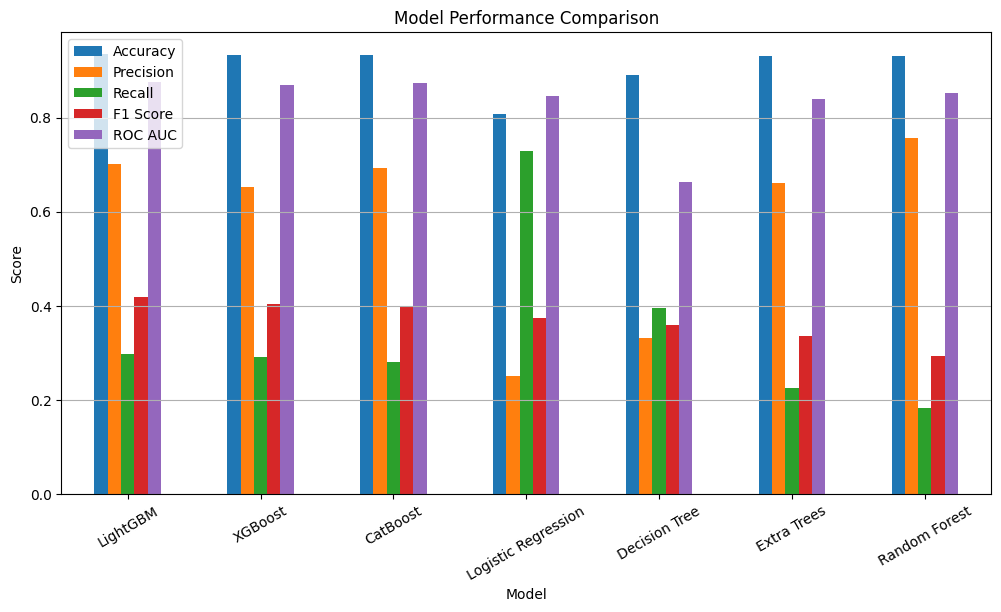

In [42]:

import matplotlib.pyplot as plt

results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    kind="bar",
    figsize=(12,6),
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=30)

plt.grid(axis="y")

plt.show()

Step 28 — Save Benchmark Results

In [44]:

results_df.to_csv(
    "../reports/model_benchmark.csv",
    index=False,
)

print("Benchmark results saved.")

Benchmark results saved.


Step 29 — Store Trained Pipelines



In [45]:
trained_models = {}

In [46]:
pipeline.fit(X_train, y_train)

trained_models[model_name] = pipeline

In [51]:
trained_models = {}

for model_name, pipeline in linear_pipelines.items():

    print(f"Training {model_name}...")

    pipeline.fit(X_train, y_train)

    # Save trained model
    trained_models[model_name] = pipeline

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
    })

Training Logistic Regression...


In [52]:
from tqdm import tqdm

# Wrap your dictionary items with tqdm for a progress bar
for model_name, pipeline in tqdm(tree_pipelines.items(), desc="Training Models"):
    pipeline.fit(X_train, y_train)
    
    # Save trained model
    trained_models[model_name] = pipeline
    
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_prob),
    })

Training Models:  67%|██████▋   | 4/6 [10:57<05:22, 161.24s/it]

[LightGBM] [Info] Number of positive: 6262, number of negative: 73290
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003869 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2032
[LightGBM] [Info] Number of data points in the train set: 79552, number of used features: 543
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.078716 -> initscore=-2.459925
[LightGBM] [Info] Start training from score -2.459925


Training Models: 100%|██████████| 6/6 [11:24<00:00, 114.01s/it]


Step 30 — Confusion Matrix

In [53]:

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

Choose the current best model:

In [54]:
print(trained_models.keys())

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'CatBoost'])


In [55]:

best_pipeline = trained_models["LightGBM"]

y_pred = best_pipeline.predict(X_test)



Plot:

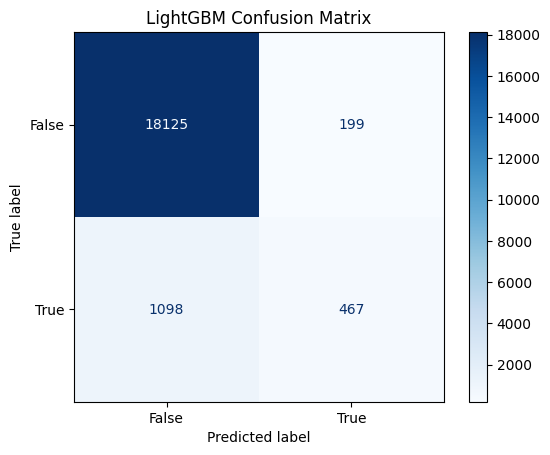

In [56]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("LightGBM Confusion Matrix")
plt.show()

Step 31 — Threshold Optimization
moving threshold from 0.50 to more lower value to increase recall and reduce false negatives. 
This is particularly important in scenarios where missing a positive case (false negative) has a higher cost than
incorrectly predicting a negative case (false positive).

Step 32 — Get Prediction Probabilities

In [57]:
# Probability of the positive class (Late Delivery = True)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

Step 33 — Evaluate Different Thresholds

In [58]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

threshold_results = []

thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1 Score": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.10,0.30,0.71,0.43
1,0.20,0.44,0.56,0.49
2,0.30,0.55,0.46,0.50
3,0.40,0.63,0.37,0.46
4,0.50,0.70,0.30,0.42
5,0.60,0.75,0.22,0.34
6,0.70,0.85,0.13,0.23
7,0.80,0.84,0.05,0.10
8,0.90,1.00,0.00,0.00


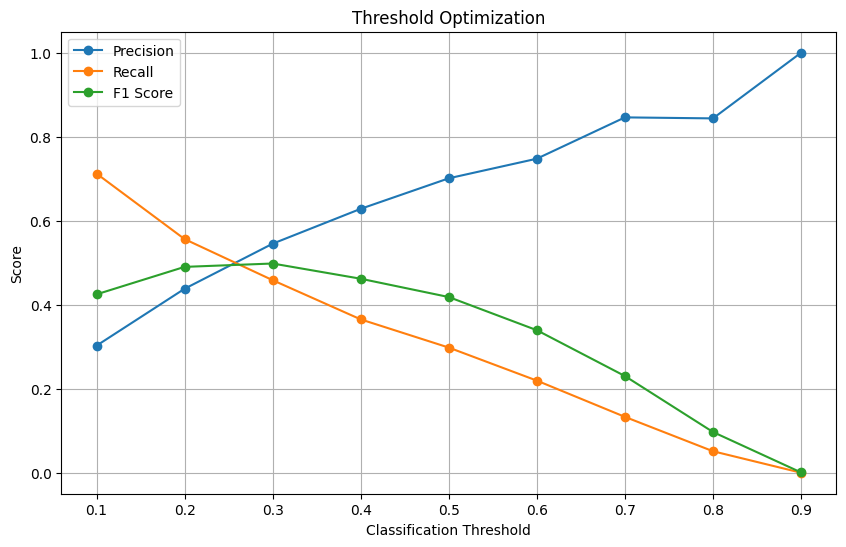

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")

plt.ylabel("Score")

plt.title("Threshold Optimization")

plt.grid(True)

plt.legend()

plt.show()

Right now our sweet spot is 0.30 threshold which gives a balance prediction and recall

WE NOW PERFORM CROSS VALIDATION TO ENSURE WHETHER WE CAN TRUST OUR MODEL ON RANDOM SPLITS WHICH PERFORMS IDENTICAL 

In [60]:
#Cell 1 — Imports
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

In [66]:
#Cell 2 — Create Cross Validation Strategy
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [67]:
#Cell 3 — Define Evaluation Metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

scoring

{'accuracy': 'accuracy',
 'precision': 'precision',
 'recall': 'recall',
 'f1': 'f1',
 'roc_auc': 'roc_auc'}

In [68]:

#Cell 4 — Create Results Container
cv_results = []

In [69]:

#Cell 5 — Cross Validate Linear Models
for model_name, pipeline in linear_pipelines.items():

    print(f"\nCross Validating {model_name}...")

    scores = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,

        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),

        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),

        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),

        "ROC AUC Mean": scores["test_roc_auc"].mean(),
        "ROC AUC Std": scores["test_roc_auc"].std(),
    })


Cross Validating Logistic Regression...


In [70]:

#Cell 6 — Cross Validate Tree Models
for model_name, pipeline in tree_pipelines.items():

    print(f"\nCross Validating {model_name}...")

    scores = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,

        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),

        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),

        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),

        "ROC AUC Mean": scores["test_roc_auc"].mean(),
        "ROC AUC Std": scores["test_roc_auc"].std(),
    })


Cross Validating Decision Tree...

Cross Validating Random Forest...

Cross Validating Extra Trees...

Cross Validating XGBoost...

Cross Validating LightGBM...

Cross Validating CatBoost...


In [71]:

#Cell 7 — Create DataFrame
cv_results_df = (
    pd.DataFrame(cv_results)
      .sort_values(
          by="F1 Mean",
          ascending=False
      )
      .reset_index(drop=True)
)

cv_results_df

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,F1 Std,ROC AUC Mean,ROC AUC Std
0,XGBoost,0.93,0.00,0.67,0.30,0.42,0.01,0.87,0.01
1,LightGBM,0.93,0.00,0.69,0.29,0.41,0.01,0.87,0.00
2,CatBoost,0.93,0.00,0.71,0.27,0.39,0.01,0.87,0.00
3,Logistic Regression,0.81,0.00,0.25,0.72,0.37,0.01,0.85,0.01
4,Decision Tree,0.89,0.00,0.33,0.39,0.35,0.01,0.66,0.01
5,Extra Trees,0.93,0.00,0.66,0.23,0.34,0.01,0.84,0.01
6,Random Forest,0.93,0.00,0.75,0.18,0.29,0.01,0.85,0.00


In [72]:

#Cell 8 — Better Formatting
cv_results_df = cv_results_df.round(4)

cv_results_df

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,F1 Std,ROC AUC Mean,ROC AUC Std
0,XGBoost,0.93,0.00,0.67,0.30,0.42,0.01,0.87,0.01
1,LightGBM,0.93,0.00,0.69,0.29,0.41,0.01,0.87,0.00
2,CatBoost,0.93,0.00,0.71,0.27,0.39,0.01,0.87,0.00
3,Logistic Regression,0.81,0.00,0.25,0.72,0.37,0.01,0.85,0.01
4,Decision Tree,0.89,0.00,0.33,0.39,0.35,0.01,0.66,0.01
5,Extra Trees,0.93,0.00,0.66,0.23,0.34,0.01,0.84,0.01
6,Random Forest,0.93,0.00,0.75,0.18,0.29,0.01,0.85,0.00


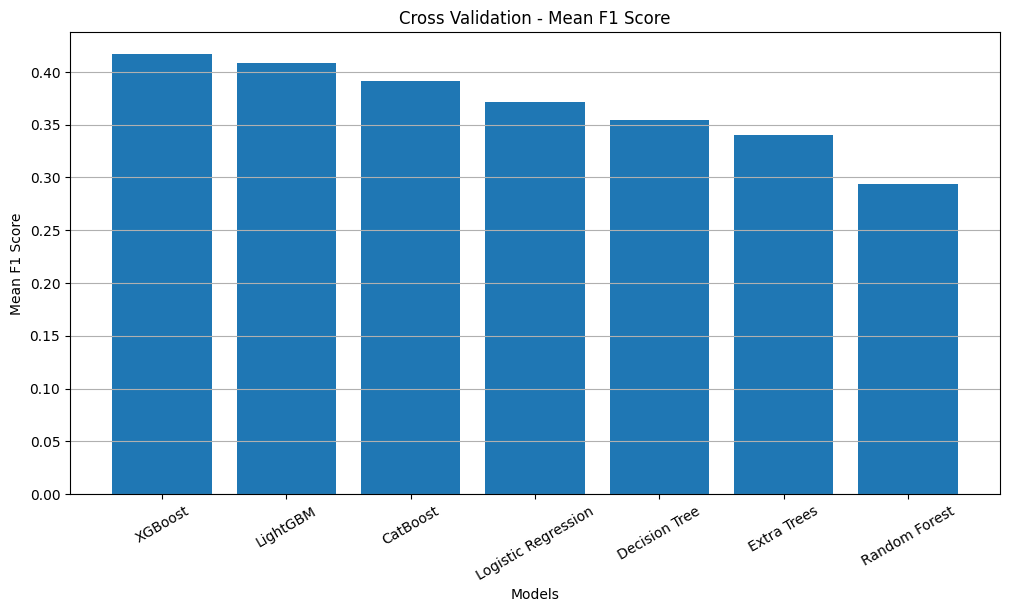

In [73]:
#Cell 9 — Plot F1 Score Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    cv_results_df["Model"],
    cv_results_df["F1 Mean"]
)

plt.title("Cross Validation - Mean F1 Score")

plt.xlabel("Models")

plt.ylabel("Mean F1 Score")

plt.xticks(rotation=30)

plt.grid(axis="y")

plt.show()

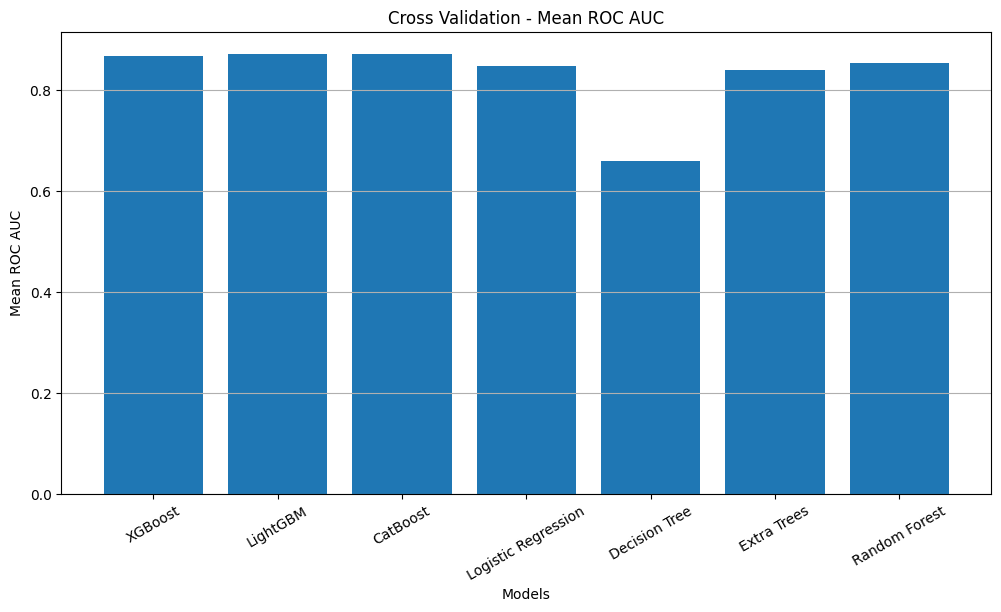

In [74]:

#Cell 10 — Plot ROC-AUC Comparison
plt.figure(figsize=(12,6))

plt.bar(
    cv_results_df["Model"],
    cv_results_df["ROC AUC Mean"]
)

plt.title("Cross Validation - Mean ROC AUC")

plt.xlabel("Models")

plt.ylabel("Mean ROC AUC")

plt.xticks(rotation=30)

plt.grid(axis="y")

plt.show()

In [75]:

#Cell 11 — Stability Analysis
stability = cv_results_df[
    [
        "Model",
        "F1 Mean",
        "F1 Std",
        "Accuracy Mean",
        "Accuracy Std",
        "ROC AUC Mean",
        "ROC AUC Std"
    ]
]

stability

,Model,F1 Mean,F1 Std,Accuracy Mean,Accuracy Std,ROC AUC Mean,ROC AUC Std
0,XGBoost,0.42,0.01,0.93,0.00,0.87,0.01
1,LightGBM,0.41,0.01,0.93,0.00,0.87,0.00
2,CatBoost,0.39,0.01,0.93,0.00,0.87,0.00
3,Logistic Regression,0.37,0.01,0.81,0.00,0.85,0.01
4,Decision Tree,0.35,0.01,0.89,0.00,0.66,0.01
5,Extra Trees,0.34,0.01,0.93,0.00,0.84,0.01
6,Random Forest,0.29,0.01,0.93,0.00,0.85,0.00


In [76]:

#Cell 12 — Select Top Models
top_models = cv_results_df.head(3)

top_models

,Model,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean,F1 Std,ROC AUC Mean,ROC AUC Std
0,XGBoost,0.93,0.00,0.67,0.30,0.42,0.01,0.87,0.01
1,LightGBM,0.93,0.00,0.69,0.29,0.41,0.01,0.87,0.00
2,CatBoost,0.93,0.00,0.71,0.27,0.39,0.01,0.87,0.00


Model Optimization phase.

We'll do it exactly like a production ML engineer.

We'll tune:

✅ XGBoost
✅ LightGBM
✅ CatBoost

using RandomizedSearchCV.


Step 43 — Hyperparameter Tuning (XGBoost)

In [77]:

#Cell 1 — Imports
from sklearn.model_selection import RandomizedSearchCV

In [78]:
#Cell 2 — Parameter Grid
xgb_param_grid = {

    "classifier__n_estimators": [100, 200, 300, 500],

    "classifier__max_depth": [3, 5, 7, 10],

    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],

    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],

    "classifier__colsample_bytree": [0.6, 0.8, 1.0],

    "classifier__min_child_weight": [1, 3, 5]
}

In [79]:
#Cell 3 — Random Search
xgb_random_search = RandomizedSearchCV(

    estimator=tree_pipelines["XGBoost"],

    param_distributions=xgb_param_grid,

    n_iter=30,

    scoring="f1",

    cv=cv,

    random_state=42,

    n_jobs=-1,

    verbose=2

)

In [80]:

#Cell 4 — Train
xgb_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': [0.6, 0.8, ...], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [3, 5, ...], 'classifier__min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variou

In [81]:

#Cell 5 — Best Parameters
print(xgb_random_search.best_params_)

{'classifier__subsample': 0.9, 'classifier__n_estimators': 500, 'classifier__min_child_weight': 3, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.2, 'classifier__colsample_bytree': 0.8}


In [82]:
#Cell 6 — Best Score
print(xgb_random_search.best_score_)

0.4339512456174666



Step 44 — Hyperparameter Tuning (LightGBM)

In [83]:

#Cell 1 — Parameter Grid
lgbm_param_grid = {

    "classifier__n_estimators": [100, 200, 300, 500],

    "classifier__max_depth": [-1, 5, 10, 15],

    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],

    "classifier__num_leaves": [31, 50, 70, 100],

    "classifier__subsample": [0.7, 0.8, 0.9, 1.0],

    "classifier__colsample_bytree": [0.6, 0.8, 1.0]

}

In [84]:

#Cell 2 — Random Search
lgbm_random_search = RandomizedSearchCV(

    estimator=tree_pipelines["LightGBM"],

    param_distributions=lgbm_param_grid,

    n_iter=30,

    scoring="f1",

    cv=cv,

    random_state=42,

    n_jobs=-1,

    verbose=2

)

In [ ]:
#Cell 3 — Train
lgbm_random_search.fit(X_train, y_train)

In [88]:

#Cell 4 — Best Parameters
print(lgbm_random_search.best_params_)

{'classifier__subsample': 1.0, 'classifier__num_leaves': 50, 'classifier__n_estimators': 300, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.2, 'classifier__colsample_bytree': 1.0}


In [87]:
#Cell 5 — Best Score
print(lgbm_random_search.best_score_)

0.42204963258602735


Step 45 — Hyperparameter Tuning (CatBoost)
SKIPPED

Step 46 — Final Comparison

After all three searches finish:

In [92]:
comparison = pd.DataFrame({

    "Model": [

        "XGBoost",

        "LightGBM",

    ],

    "CV F1 Before Tuning": [

        0.42,

        0.41,

    ],

    "CV F1 After Tuning": [

        xgb_random_search.best_score_,

        lgbm_random_search.best_score_,

    ]

})

comparison

,Model,CV F1 Before Tuning,CV F1 After Tuning
0,XGBoost,0.42,0.43
1,LightGBM,0.41,0.42


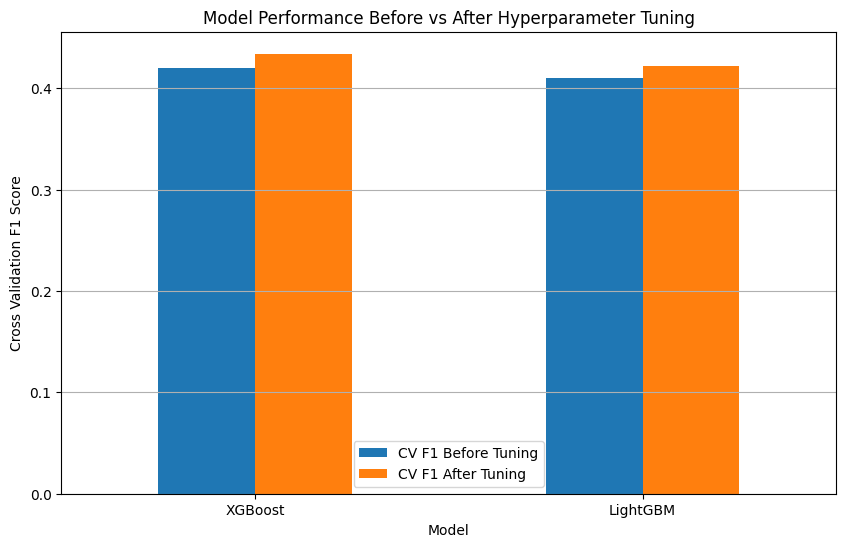

In [93]:

#Step 47 — Plot Improvement
import matplotlib.pyplot as plt

comparison.plot(

    x="Model",

    y=["CV F1 Before Tuning", "CV F1 After Tuning"],

    kind="bar",

    figsize=(10,6)

)

plt.title("Model Performance Before vs After Hyperparameter Tuning")

plt.ylabel("Cross Validation F1 Score")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

In [94]:
best_xgb = xgb_random_search.best_estimator_

best_xgb

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

In [95]:
#Cell 2 — Predict on Test Set
y_pred = best_xgb.predict(X_test)

y_prob = best_xgb.predict_proba(X_test)[:, 1]

In [96]:
#Cell 3 — Evaluate Final Model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

final_metrics = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value": [

        accuracy_score(y_test, y_pred),

        precision_score(y_test, y_pred),

        recall_score(y_test, y_pred),

        f1_score(y_test, y_pred),

        roc_auc_score(y_test, y_prob)

    ]

})

final_metrics

,Metric,Value
0,Accuracy,0.93
1,Precision,0.66
2,Recall,0.33
3,F1 Score,0.44
4,ROC AUC,0.87


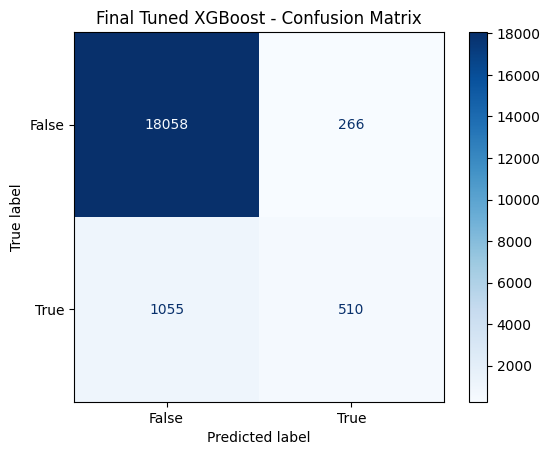

In [97]:
#Cell 4 — Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Final Tuned XGBoost - Confusion Matrix")

plt.show()

In [98]:
#Cell 5 — Classification Report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.94      0.99      0.96     18324
        True       0.66      0.33      0.44      1565

    accuracy                           0.93     19889
   macro avg       0.80      0.66      0.70     19889
weighted avg       0.92      0.93      0.92     19889



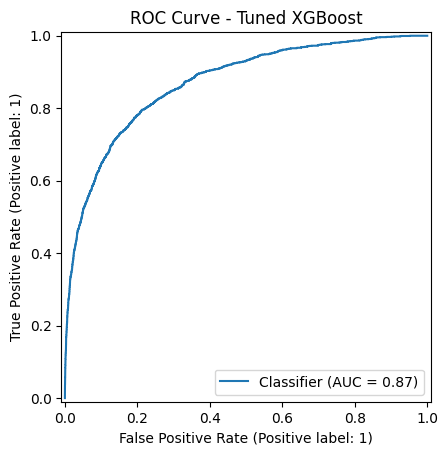

In [99]:
#Cell 6 — ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve - Tuned XGBoost")

plt.show()

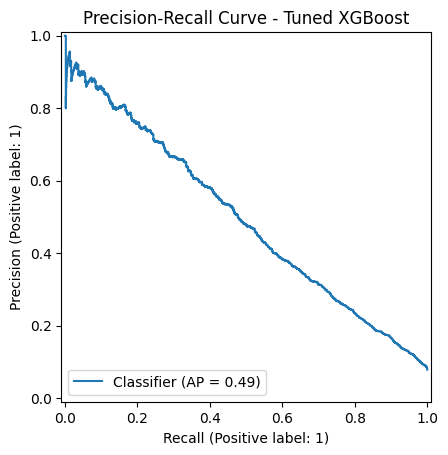

In [100]:
#Cell 7 — Precision-Recall Curve
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Precision-Recall Curve - Tuned XGBoost")

plt.show()

In [102]:
#Cell 8 — Compare Before vs After Tuning
comparison = pd.DataFrame({

    "Metric":[
        "F1 Score",
        "ROC AUC"
    ],

    "Before Tuning":[
        0.42,
        0.87
    ],

    "After Tuning":[
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]

})

comparison

,Metric,Before Tuning,After Tuning
0,F1 Score,0.42,0.44
1,ROC AUC,0.87,0.87


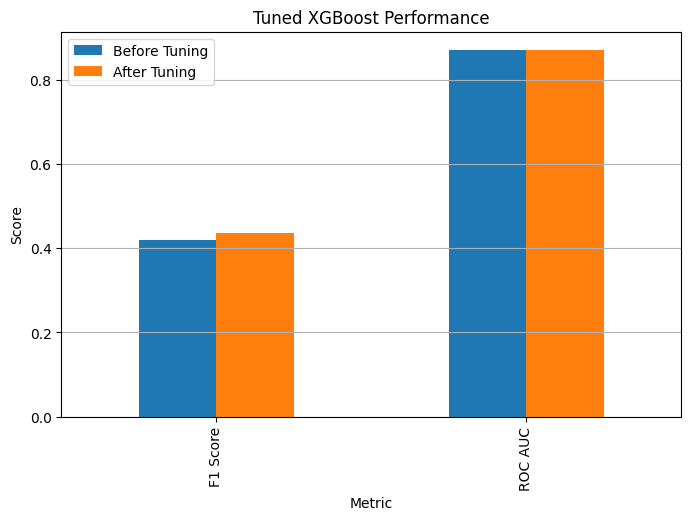

In [103]:
#Cell 9 — Plot Improvement
comparison.plot(
    x="Metric",
    kind="bar",
    figsize=(8,5)
)

plt.title("Tuned XGBoost Performance")

plt.ylabel("Score")

plt.grid(axis="y")

plt.show()

Phase 2 — Explain the Model

Before deploying, a business stakeholder will ask:

"Why did the model predict this order as late?"

We need interpretability.

We'll do:


Step 47 — Feature Importance

Questions answered:

Which features influence late delivery the most?
Is shipping time more important than payment type?
Does review score matter?
Does customer state matter?

In [104]:
#Cell 1 — Import Libraries
from matplotlib.table import Cell
import numpy as np
import matplotlib.pyplot as plt





Remember:

Our model is inside a Pipeline.

The pipeline looks like:

Preprocessor
        ↓
XGBoost

We need the transformed feature names.

In [105]:
#Cell 2 — Extract Feature Names

preprocessor = best_xgb.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

len(feature_names)

3942

In [106]:
#Cell 3 — Extract Feature Importance
xgb_model = best_xgb.named_steps["classifier"]

importance = xgb_model.feature_importances_

len(importance)

3942

In [107]:
#Cell 4 — Create Importance DataFrame
importance_df = pd.DataFrame({

    "Feature": feature_names,
    "Importance": importance

})

importance_df = (
    importance_df
        .sort_values(
            by="Importance",
            ascending=False
        )
        .reset_index(drop=True)
)

importance_df.head(20)


,Feature,Importance
0,bool__is_in_progress,0.41
1,bool__low_rating,0.05
2,bool__is_delivered,0.04
3,bool__high_rating,0.04
4,cat__purchase_month_name_June,0.01
5,cat__customer_state_SP,0.01
6,cat__customer_state_RJ,0.01
7,cat__purchase_month_name_January,0.01
8,cat__customer_state_MG,0.01
9,cat__customer_state_AL,0.01


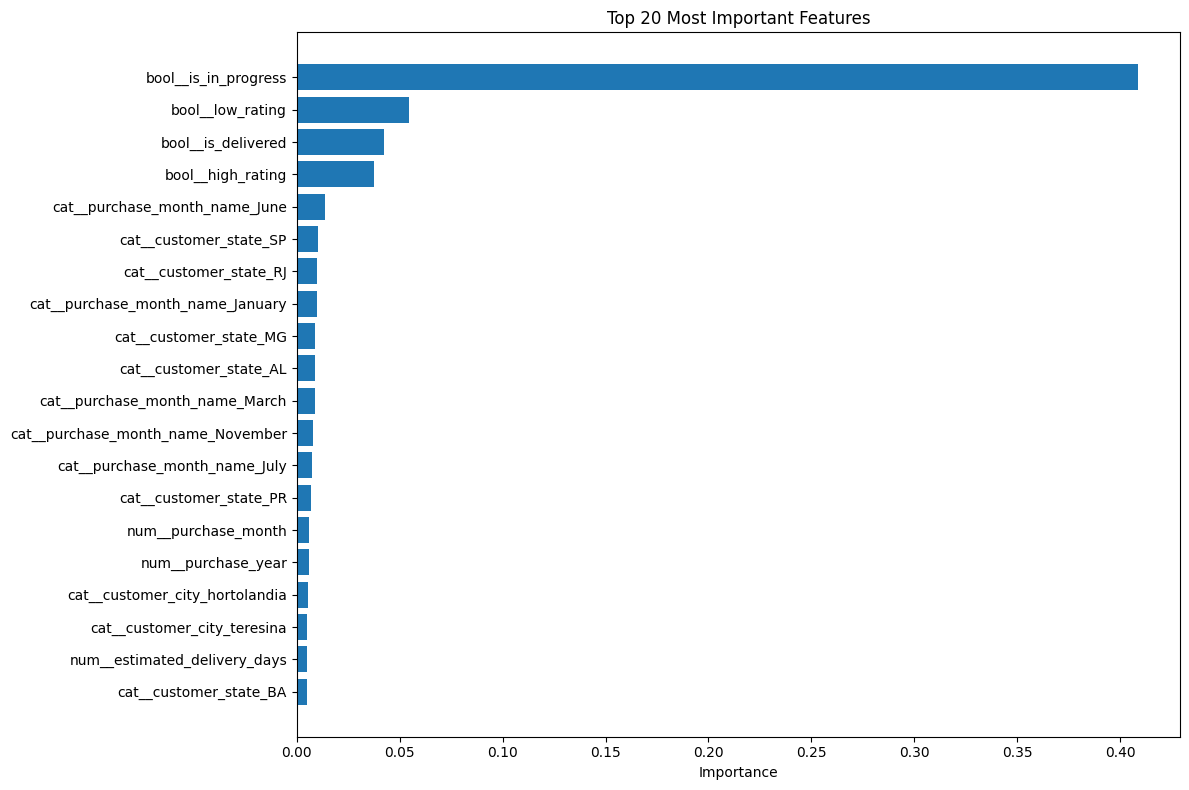

In [108]:
#Cell 5 — Plot Top 20 Features
top20 = importance_df.head(20)

plt.figure(figsize=(12,8))

plt.barh(
    top20["Feature"],
    top20["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Most Important Features")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

In [109]:

#Cell 6 — Save Feature Importance
importance_df.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


### SHAP EXPLAINABILITY 

## 🧠 Reasoning First

Feature Importance explains

> **Which features matter overall?**

But it cannot answer:

> **Why was THIS specific order predicted as late?**

SHAP answers exactly that.

For every prediction, SHAP tells us

- Which features increased the probability.
- Which features decreased the probability.
- By how much.

This provides a **local explanation** for individual predictions.


In [ ]:
#Cell 1 — Install SHAP (Run only once)
#!pip install shap

In [111]:
#Cell 2 — Import
import shap

C:\Users\Steve\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [112]:
#Cell 3 — Transform the Test Data

#The SHAP explainer expects the same transformed features that the model receives.

X_test_processed = preprocessor.transform(X_test)
#Cell 4 — Create SHAP Explainer
explainer = shap.TreeExplainer(xgb_model)
#Cell 5 — Compute SHAP Values
shap_values = explainer.shap_values(X_test_processed)


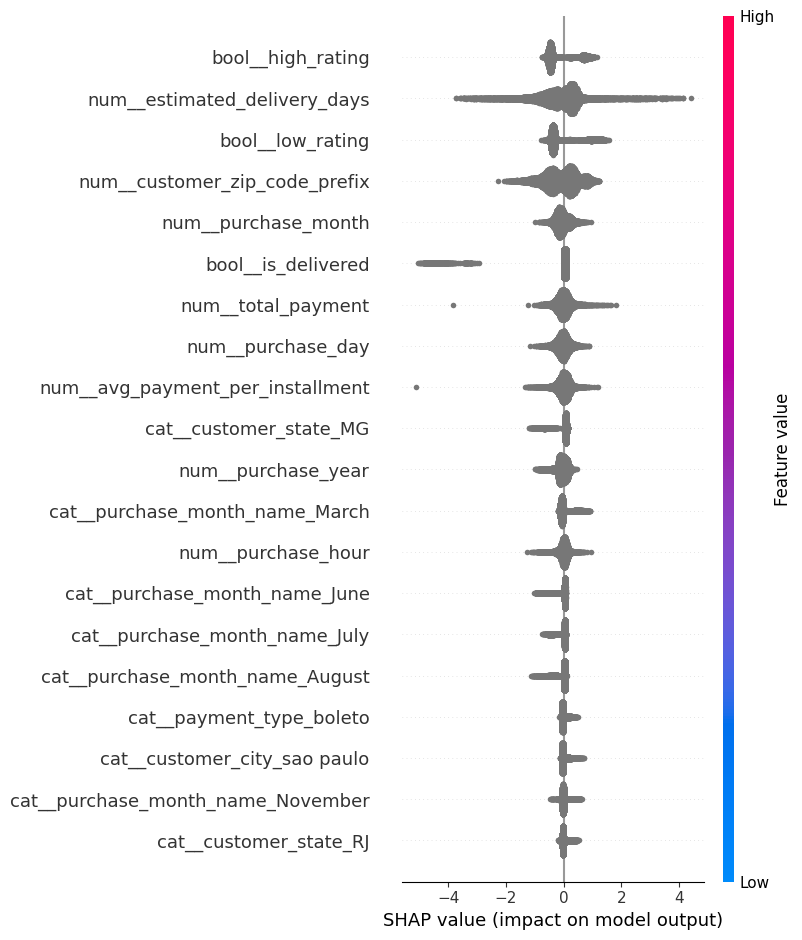

In [113]:
#Cell 6 — SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

#This is one of the most important explainability plots in ML.

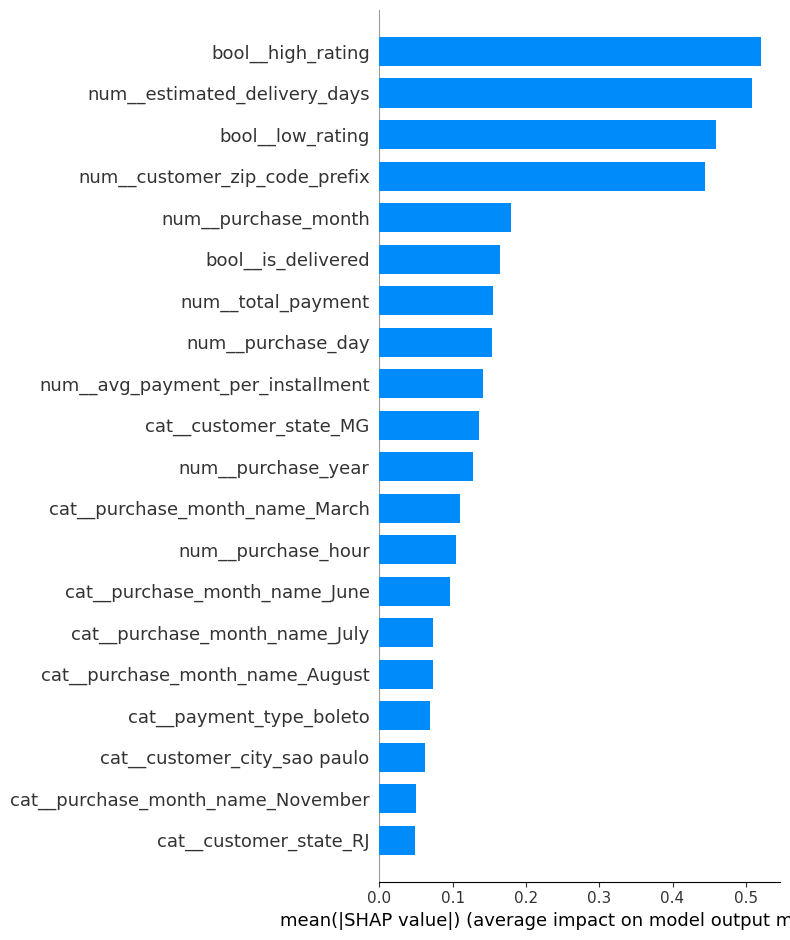

In [114]:

#Cell 7 — SHAP Bar Plot
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar"
)

#This provides a global ranking of feature influence based on SHAP values.

IndexError: index (3938) out of range

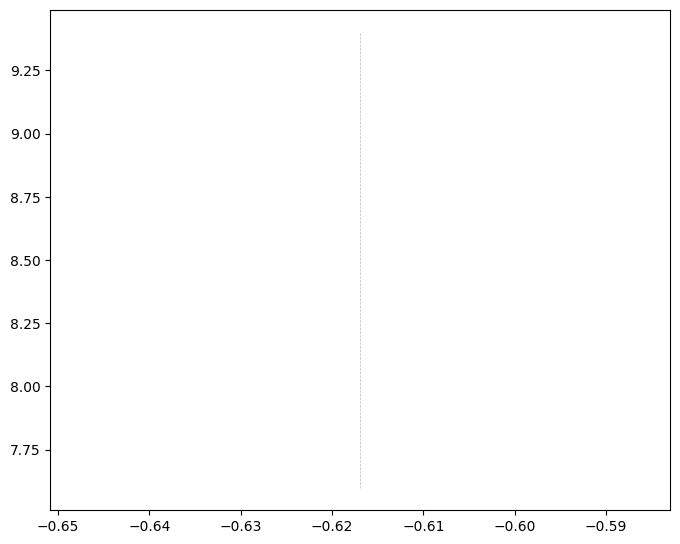

In [115]:
#Cell 8 — Explain One Prediction

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test_processed[0],
        feature_names=feature_names
    )
)

In [116]:
print(X.columns.tolist())

['order_purchase_timestamp', 'order_estimated_delivery_date', 'approval_after_carrier_flag', 'delivery_before_carrier_flag', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'total_payment', 'payment_count', 'payment_type', 'max_installments', 'purchase_year', 'purchase_month', 'purchase_month_name', 'purchase_quarter', 'purchase_day', 'purchase_weekday', 'purchase_hour', 'estimated_delivery_days', 'avg_payment_per_installment', 'multiple_payment_methods', 'high_rating', 'low_rating', 'is_delivered', 'is_cancelled', 'is_in_progress']


In [117]:
print(boolean_features)

['approval_after_carrier_flag', 'delivery_before_carrier_flag', 'multiple_payment_methods', 'high_rating', 'low_rating', 'is_delivered', 'is_cancelled', 'is_in_progress']


In [118]:
leakage_features = [
    "high_rating",
    "low_rating",
    "is_delivered",
    "is_in_progress",
    "review_score",
    "review_comment_title",
    "review_comment_message",
    "delivery_delay_days",
    "delivery_time_days",
    "total_order_cycle_days",
]

print(set(leakage_features).intersection(set(X.columns)))

{'low_rating', 'is_delivered', 'high_rating', 'is_in_progress'}
